# Funding Rate Carry: what survives execution costs?

Perpetual futures have no expiry, so a periodic **funding rate** is paid between longs and shorts
to keep the contract near spot. A position that is long one perpetual and short another is
directionally flat but still collects the difference between the two funding rates.

That is the trade this notebook measures. The question is not whether the funding spread exists —
it plainly does — but **how much of it survives execution costs, and what is actually being paid
for.**

The analysis covers three assets across four venues over roughly two years of public data, and
arrives at a conclusion that runs against the intuition the strategy invites: the spread is real,
but almost every attempt to *trade* it turns a positive carry into a negative one.

In [1]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
from IPython.display import Image, display

from src import analysis, fetch, pipeline, plots

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
pd.options.display.float_format = "{:,.2f}".format

COINS = pipeline.COINS
FOCUS = "/".join(pipeline.FOCUS_PAIR)      # binance/hyperliquid - exchange vs DEX
CONTROL = "/".join(pipeline.CONTROL_PAIR)  # binance/bybit      - exchange vs exchange
FIG = "../figures"

## 1. Data

Four venues, chosen to span the two market structures that matter here: three centralised
order-book exchanges (Binance, Bybit, OKX) and one on-chain perpetual DEX (Hyperliquid).
Everything comes from public REST endpoints — no API keys, no authentication — and is cached
locally so the analysis is reproducible against a fixed snapshot.

In [2]:
data = pipeline.load_funding()

coverage = pd.DataFrame({
    coin: {venue: f"{len(df):,} pts · {df['interval_hours'].iloc[0]:.0f}h · "
                  f"{df['time'].min():%Y-%m} to {df['time'].max():%Y-%m}"
           for venue, df in venues.items()}
    for coin, venues in data.items()
})
coverage

,BTC,ETH,SOL
binance,"3,000 pts · 8h · 2023-11 to 2026-07","3,000 pts · 8h · 2023-11 to 2026-07","3,000 pts · 8h · 2023-11 to 2026-07"
bybit,"5,000 pts · 8h · 2022-01 to 2026-07","5,000 pts · 8h · 2022-01 to 2026-07","5,000 pts · 8h · 2022-05 to 2026-07"
okx,274 pts · 8h · 2026-04 to 2026-07,274 pts · 8h · 2026-04 to 2026-07,274 pts · 8h · 2026-04 to 2026-07
hyperliquid,"18,210 pts · 1h · 2024-07 to 2026-07","18,210 pts · 1h · 2024-07 to 2026-07","18,210 pts · 1h · 2024-07 to 2026-07"


### The units trap

Venues publish funding over different intervals. Binance, Bybit and OKX quote a rate per
**8-hour** period; Hyperliquid quotes a rate per **hour**. Comparing the published numbers
directly makes the centralised venues look eight times more generous than they are, and every
downstream decision inherits that error with the wrong sign.

The interval is therefore *inferred from the timestamps* rather than assumed, because venues do
change it — Binance moves volatile symbols to a 4-hour schedule — and a hard-coded constant would
fail silently on exactly the symbols where the spread is widest.

In [3]:
units = pd.DataFrame({
    venue: {
        "published rate (last print)": df["funding_rate"].iloc[-1],
        "inferred interval (h)": df["interval_hours"].iloc[-1],
        "normalised per hour": df["rate_per_hour"].iloc[-1],
        "annualised %": df["annualised_pct"].iloc[-1],
    }
    for venue, df in data["BTC"].items()
}).T
units

,published rate (last print),inferred interval (h),normalised per hour,annualised %
binance,0.00,8.00,0.00,4.01
bybit,0.00,8.00,0.00,10.49
okx,0.00,8.00,0.00,9.12
hyperliquid,0.00,1.00,0.00,9.62


## 2. Is there a carry on a single venue?

The classic version of this trade is one-sided: short the perpetual, hold the asset, collect
funding. Restricting the comparison to the window all four venues share matters — a venue measured
over a bull run against one measured over a drawdown tells you about the sample, not the venue.

In [4]:
single = {coin: analysis.compare_venues(data[coin], common_window=True) for coin in COINS}
single["BTC"][["annualised_mean_pct", "annualised_median_pct",
               "pct_periods_negative", "worst_period_annualised_pct"]]

,annualised_mean_pct,annualised_median_pct,pct_periods_negative,worst_period_annualised_pct
binance,3.78,4.31,18.98,-10.02
bybit,2.55,2.80,28.83,-10.06
okx,2.98,3.14,25.55,-8.55
hyperliquid,6.03,9.87,17.48,-23.81


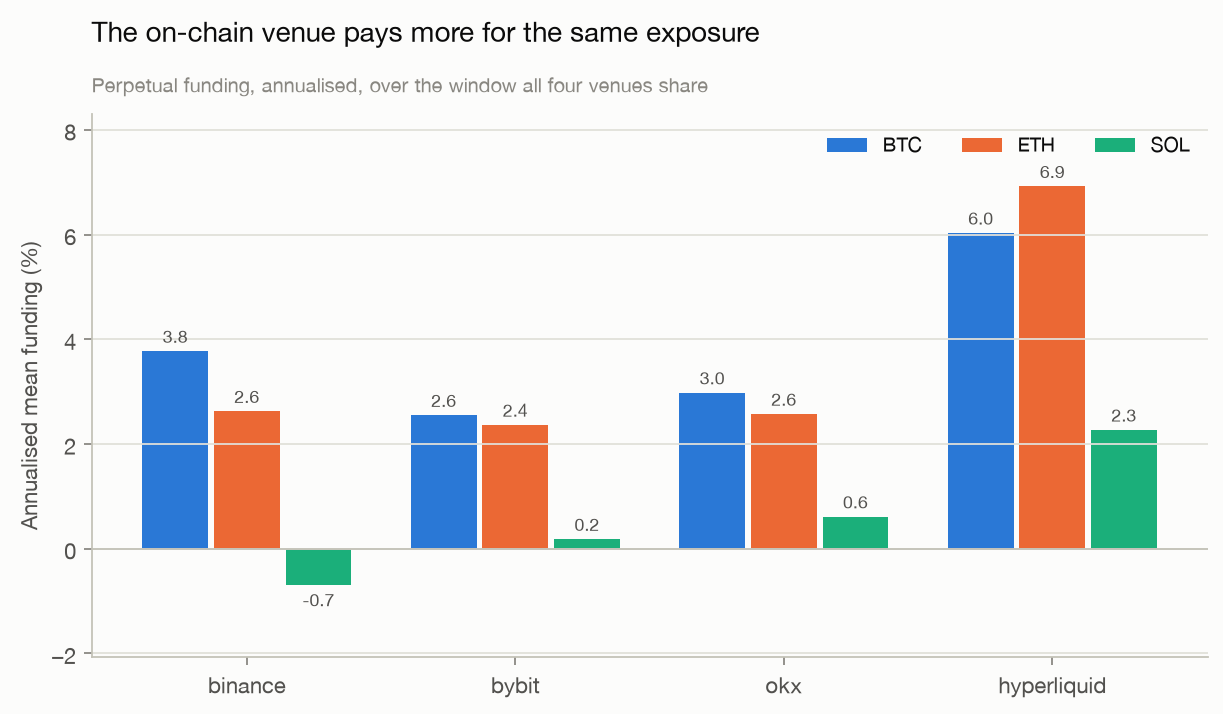

In [5]:
display(Image(filename=f"{FIG}/venue_funding.png"))

Two things stand out.

**The level is modest.** Mid-single-digit annualised percentages, before any cost. That is not the
double-digit yield the strategy is usually pitched at.

**The sign is not reliable.** Funding is negative in a meaningful share of periods — for SOL it is
close to a coin flip — so a position held for the carry is regularly paying instead of earning.
Delta-neutral means neutral to *price*, not neutral to *outcome*.

The on-chain venue consistently pays more than the centralised ones. That difference, not the
level on any single venue, is where the rest of this analysis goes.

## 3. The cross-venue spread

Long one perpetual and short the other, and the income becomes the difference between two funding
rates. To tell a real bias from noise, the exchange-vs-DEX pair is measured alongside a **control**:
two centralised exchanges of the same type, where no structural difference should exist.

In [6]:
spreads = pipeline.build_spreads(data)
analysis.spread_summary(spreads["SOL"])[
    ["hours", "mean_abs_annualised_pct", "p90_abs_annualised_pct",
     "pct_hours_above_10pct", "sign_stability_pct"]
]

,hours,mean_abs_annualised_pct,p90_abs_annualised_pct,pct_hours_above_10pct,sign_stability_pct
binance/bybit,23992,5.91,13.93,19.07,47.12
binance/okx,2184,3.72,7.74,4.76,61.54
binance/hyperliquid,18208,11.40,24.37,41.73,64.83
bybit/okx,2184,5.39,11.31,15.75,49.45
bybit/hyperliquid,18208,11.15,24.82,41.16,55.66
okx/hyperliquid,2184,7.57,15.12,29.53,60.90


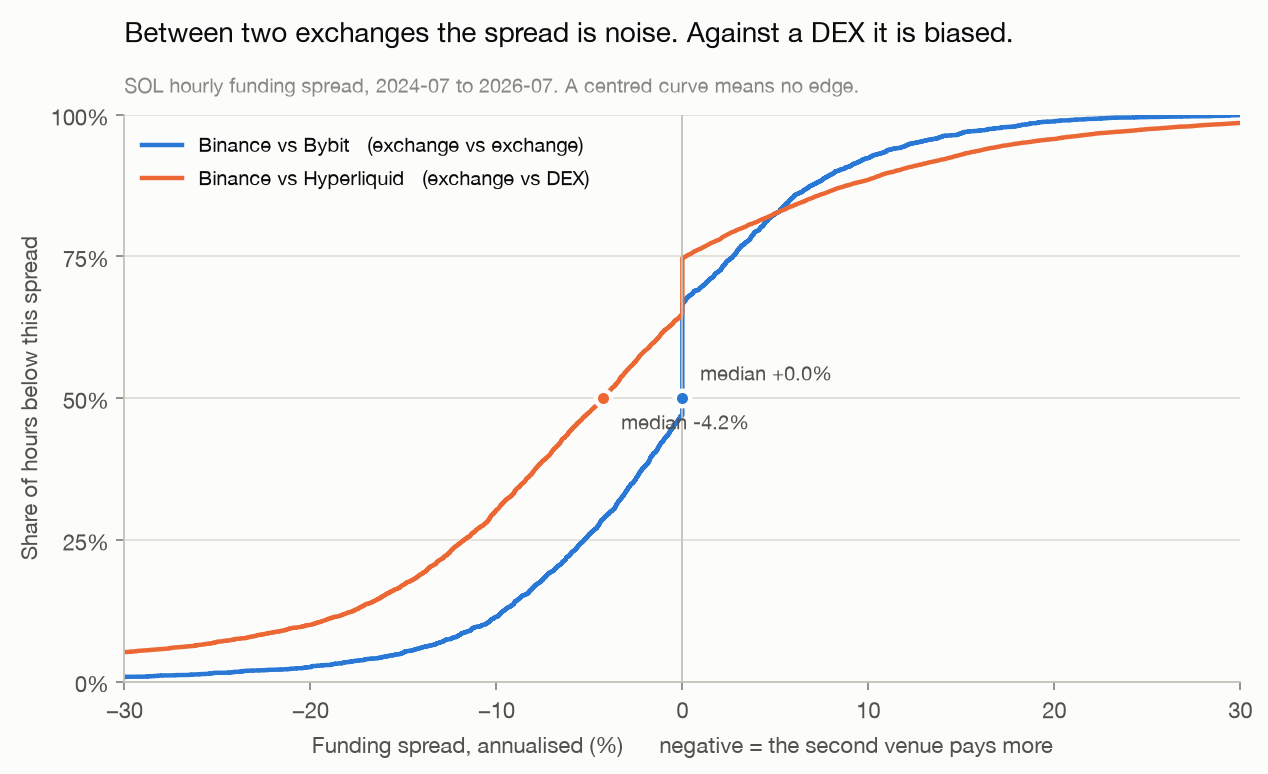

In [7]:
display(Image(filename=f"{FIG}/spread_bias.png"))

The control behaves exactly as it should: the Binance/Bybit spread is centred on zero and its sign
is a coin flip (`sign_stability` near 50%). Two venues of the same type, arbitraged by the same
participants, do not persistently disagree.

The exchange-versus-DEX pair does not behave that way. Its median sits several percent below zero
and the sign holds in roughly two thirds of hours. That is a structural bias, and it has a
plausible mechanism: the on-chain venue has a smaller, more directional, more leverage-hungry
participant base, and fewer arbitrageurs willing to hold inventory across two settlement systems
to close the gap.

**But persistence of *sign* is not persistence of *value*.** An AR(1) fit puts the half-life of the
spread itself at a few hours.

In [8]:
halflife = pd.DataFrame({
    coin: {pair: analysis.spread_halflife(df) for pair, df in pairs.items()}
    for coin, pairs in spreads.items()
}).T
halflife.round(1)

,binance/bybit,binance/okx,binance/hyperliquid,bybit/okx,bybit/hyperliquid,okx/hyperliquid
BTC,10.90,6.90,3.10,8.30,2.90,4.00
ETH,9.30,8.60,3.50,8.40,3.10,4.40
SOL,6.90,6.10,1.50,7.90,1.50,3.20


So the signal has two clocks. Its *direction* is a regime that lasts months; its *level* mean-reverts
within hours. Any rule that reacts to the level is trading noise at full cost. This is the single
most important fact in the analysis, and section 5 is what happens when it is ignored.

## 4. What it costs to trade it

A delta-neutral pair has two legs, and each leg is opened and closed, so one complete round trip
crosses the market four times. Fees are contractual and known in advance; slippage is a realised
outcome. They are modelled separately so it is visible which part is negotiable.

In [9]:
profiles = pd.DataFrame({
    name: {"entry fee (bps/leg/side)": m.entry_fee_bps,
           "exit fee (bps/leg/side)": m.exit_fee_bps,
           "slippage (bps/leg/side)": m.slippage_bps,
           "round trip (bps)": m.round_trip_bps}
    for name, m in analysis.COST_PROFILES.items()
}).T
profiles

,entry fee (bps/leg/side),exit fee (bps/leg/side),slippage (bps/leg/side),round trip (bps)
taker/taker (retail CEX),4.50,4.50,1.00,22.00
maker/taker (mixed),1.00,4.50,0.50,13.00
maker/maker (passive both legs),1.00,1.00,0.50,6.00
on-chain maker (DEX rebate tier),0.50,0.50,0.50,4.00


In [10]:
edges = {coin: spreads[coin][FOCUS]["abs_spread"].mean() for coin in COINS}
analysis.breakeven_table(edges).round(0)

,annualised_edge_pct,taker/taker (retail CEX),maker/taker (mixed),maker/maker (passive both legs),on-chain maker (DEX rebate tier)
edge,,,,,
BTC,8.00,228.00,135.00,62.00,41.00
ETH,9.00,223.00,132.00,61.00,40.00
SOL,11.00,169.00,100.00,46.00,31.00


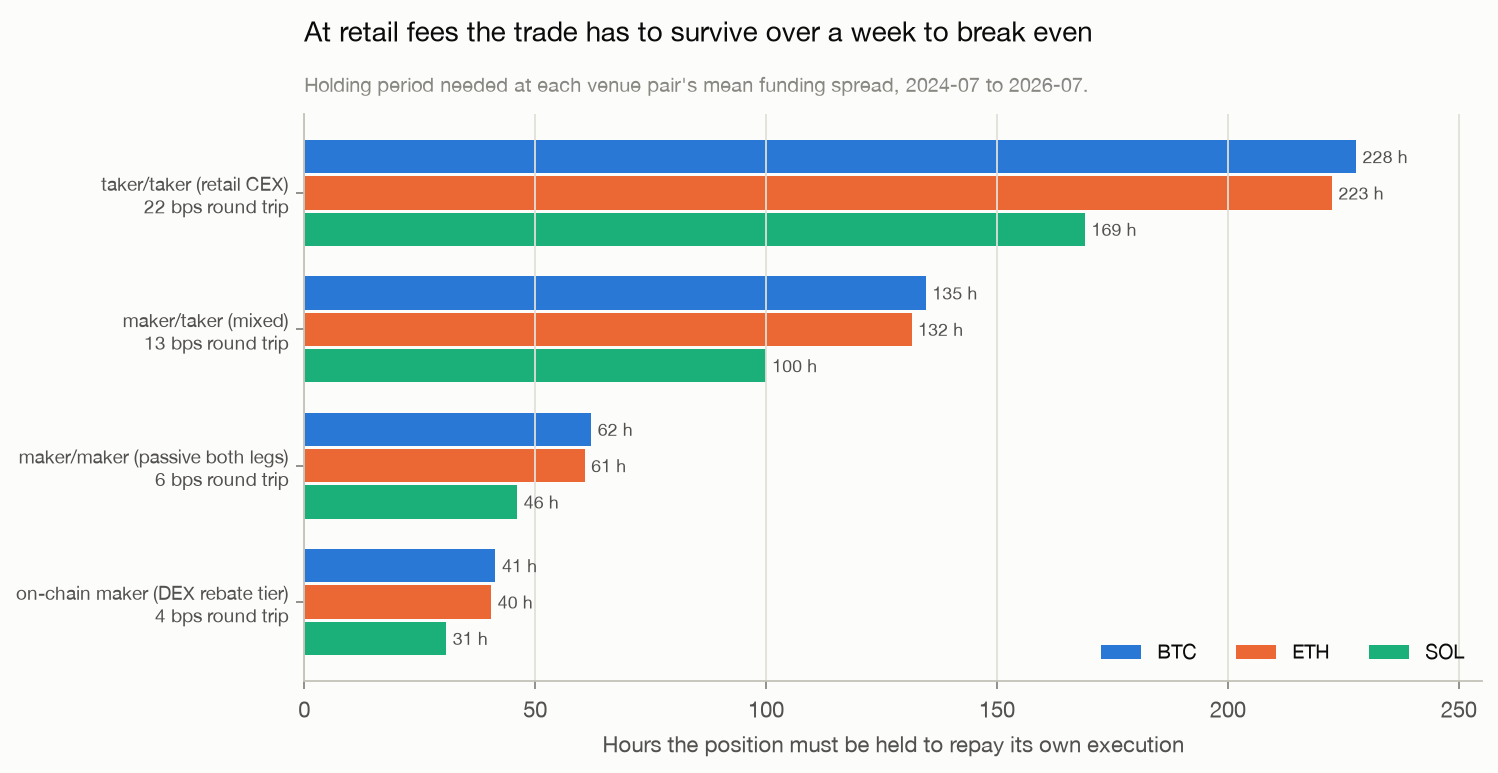

In [11]:
display(Image(filename=f"{FIG}/breakeven.png"))

This table is the whole economic problem in one place. At retail taker fees the position has to
survive **over a week** before it has repaid its own execution. Even at the cheapest on-chain maker
tier it needs well over a day.

Against a spread whose half-life is a few hours, that is a very unforgiving arithmetic.

## 5. Three decision rules

Same signal, same data, same costs. Only the decision rule changes.

1. **Passive hold** — pick a side from the first eight hours and never revisit it. One round trip.
2. **Active rotation** — enter when the trailing 8-hour spread clears 10% annualised and its sign
   has been consistent, exit when it decays below 3%. This is the rule the signal *invites*.
3. **Slow side** — stay in the market permanently and re-examine only *which* venue to short, on a
   30-day clock. Costs are paid only when the side genuinely flips.

The side is fixed at entry and held for the life of the position in all three. Recomputing the
favourable side each hour would be look-ahead: the direction is only knowable once the rate prints.

In [12]:
base = analysis.COST_PROFILES[pipeline.BASE_PROFILE]
summary = pipeline.strategy_summary(spreads, base)
summary[["annualised_return_pct", "gross_return_pct", "total_costs_pct",
         "round_trips", "time_in_market_pct", "pct_hours_paying", "max_drawdown_pct"]]

annualised_return_pct  gross_return_pct  total_costs_pct  round_trips  time_in_market_pct  pct_hours_paying  max_drawdown_pct
BTC Slow side (30-day review)                            5.44             11.43             0.13         1.00               96.05             16.92             -0.16
    Active rotation (8-hour signal)                     -9.04             10.58            29.38       226.00               39.49              5.21            -18.80
    Passive hold (side fixed at start)                  -5.78            -11.88             0.13         1.00               99.96             72.35            -12.09
ETH Slow side (30-day review)                            2.70              6.25             0.65         5.00               96.05             24.36             -1.84
    Active rotation (8-hour signal)                    -10.50             10.42            32.24       248.00               39.61              7.96            -21.82
    Passive hold (side fixed at start)                   4.59              9.67             0.13         1.00               99.96             20.97             -0.57
SOL Slow side (30-day review)                            4.36              9.71             0.65         5.00               96.05             27.95             -0.91
    Active rotation (8-hour signal)                    -15.16             14.50            46.02       354.00               51.66              9.62            -31.52
    Passive hold (side fixed at start)                  -5.35            -10.98             0.13         1.00               99.96             64.82            -11.12

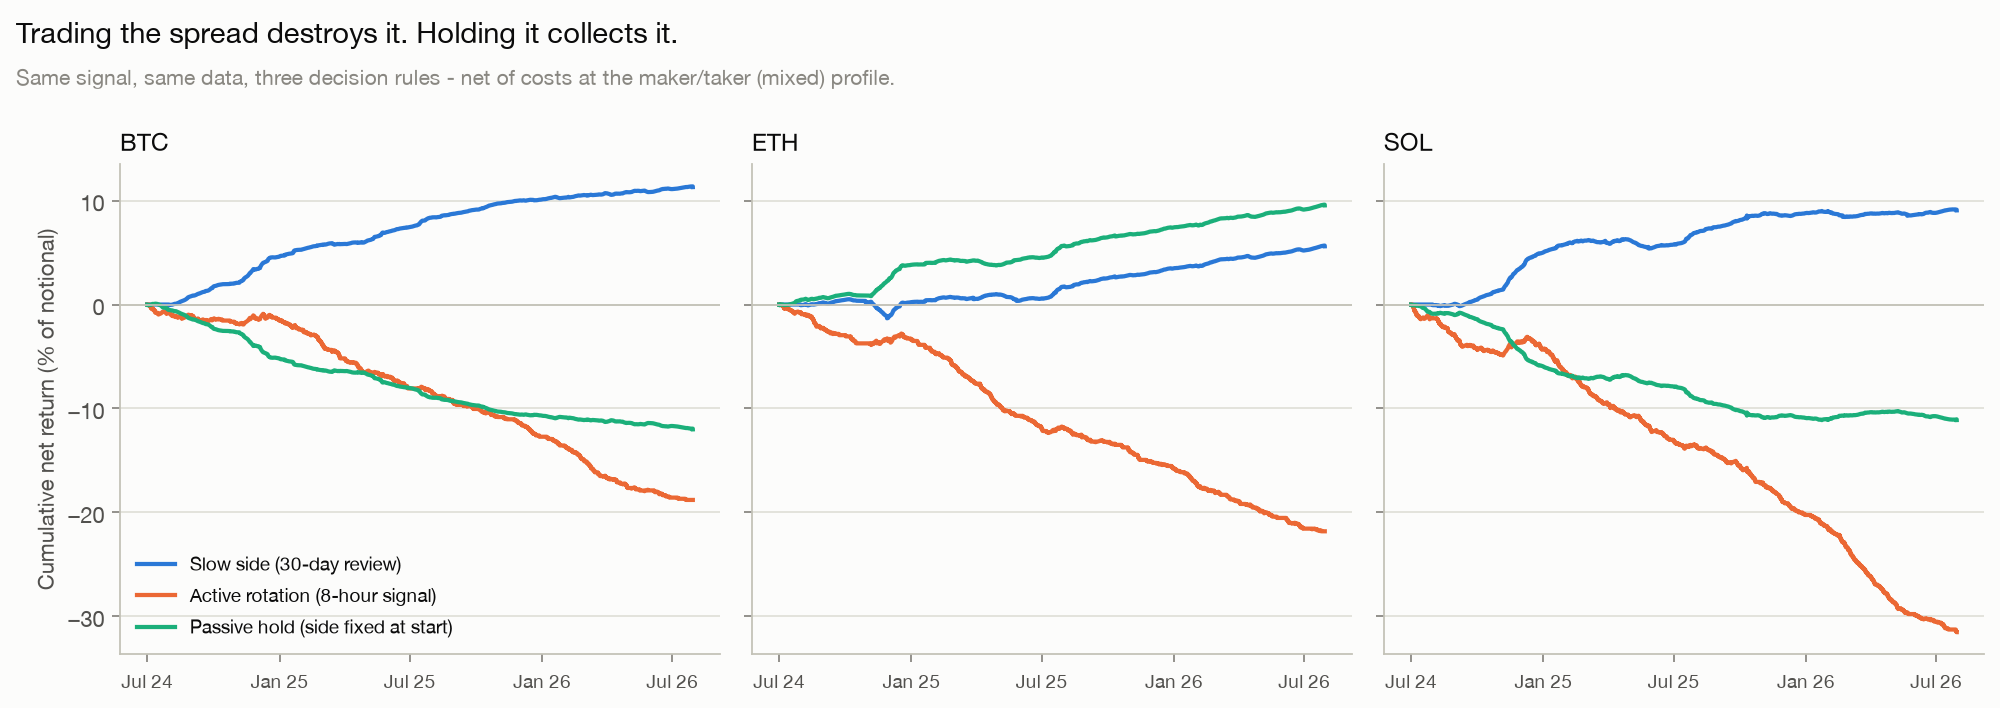

In [13]:
display(Image(filename=f"{FIG}/strategies.png"))

The active rule earns the **most gross** and finishes deeply negative. It is not a bad signal
badly used — it is a good signal traded at a frequency its own half-life cannot support. Costs
exceed gross income by a factor of three.

The passive rule fails for a different and more interesting reason: with the side chosen from eight
hours of data it picked the wrong venue to short on two of the three assets and simply paid funding
for two years. It is not a carry strategy at all — it is one unhedged bet on the funding regime,
made once, with no mechanism to notice it was wrong.

The slow rule wins by declining to trade. It holds through the noise, pays for one to five round
trips across two years, and captures most of the structural bias.

## 6. How much of this depends on execution?

If the conclusion is fragile to the fee assumption, it is not a conclusion. So the same three rules
are run across four cost profiles, from retail taker fees down to an on-chain maker rebate tier.

In [14]:
pipeline.cost_ladder(spreads).round(2)

,Slow side (30-day review),Active rotation (8-hour signal),Passive hold (side fixed at start)
taker/taker (retail CEX),4.00,-23.52,-2.22
maker/taker (mixed),4.16,-11.57,-2.18
maker/maker (passive both legs),4.29,-2.27,-2.14
on-chain maker (DEX rebate tier),4.32,0.38,-2.13


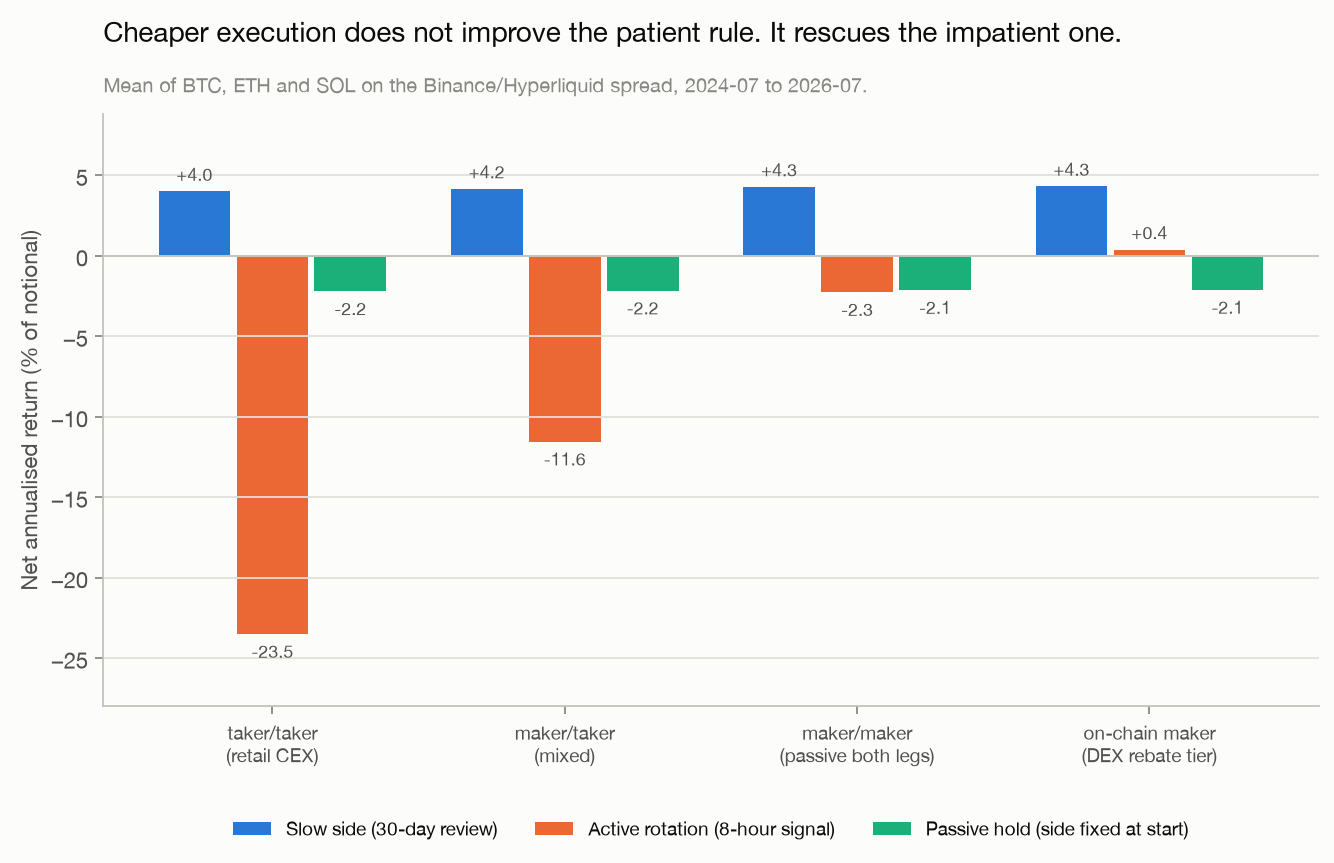

In [15]:
display(Image(filename=f"{FIG}/cost_ladder.png"))

The ranking never changes. Cheaper execution does not make the patient rule better — it barely
moves it, because it hardly trades. What cheaper execution does is *rescue the impatient rule*,
dragging it from roughly −24% a year to about break-even.

That reframes what execution quality buys. It is not an edge; it is permission to be wrong about
frequency.

A complementary way to see it: the round-trip cost at which each rule's return crosses zero.

In [16]:
def breakeven_bps(run, spread, lo=0.0, hi=400.0):
    """Bisect on the round-trip cost at which annualised return hits zero."""
    for _ in range(50):
        mid = (lo + hi) / 2
        probe = analysis.CostModel("probe", mid / 8, mid / 8, 0.0)
        if analysis.backtest_summary(run(spread, probe))["annualised_return_pct"] > 0:
            lo = mid
        else:
            hi = mid
    return lo

tolerance = pd.DataFrame({
    coin: {
        "slow side (30d)": breakeven_bps(analysis.backtest_slow_side, spreads[coin][FOCUS]),
        "active rotation": breakeven_bps(
            lambda s, m: analysis.backtest_spread(s, m, entry_annual_pct=10.0, exit_annual_pct=3.0),
            spreads[coin][FOCUS]),
    }
    for coin in COINS
}).T
tolerance.round(1)

,slow side (30d),active rotation
BTC,400.00,9.40
ETH,250.10,8.40
SOL,388.40,8.20


The patient rule tolerates a round-trip cost an order of magnitude larger than the impatient one.
A strategy that only survives below roughly 8 bps has no margin for a bad fill, a fee-tier change,
or a widening book.

## 7. Is the opportunity still there?

A two-year average is a poor guide to a market that is being competed away. Splitting it by quarter
is the cheapest check available.

In [17]:
quarterly = {coin: analysis.quarterly_profile(spreads[coin][FOCUS]) for coin in COINS}
quarterly["SOL"][["mean_abs_annualised_pct", "mean_signed_annualised_pct", "pct_hours_above_10pct"]]

,mean_abs_annualised_pct,mean_signed_annualised_pct,pct_hours_above_10pct
quarter,,,
2024Q3,11.32,-5.33,40.81
2024Q4,19.10,-18.07,58.70
2025Q1,12.14,-4.85,50.14
2025Q2,10.96,-2.94,43.68
2025Q3,10.93,-9.33,41.80
2025Q4,11.13,-2.67,36.78
2026Q1,9.44,2.26,37.55
2026Q2,7.63,-1.55,31.09
2026Q3,6.50,-3.86,20.35


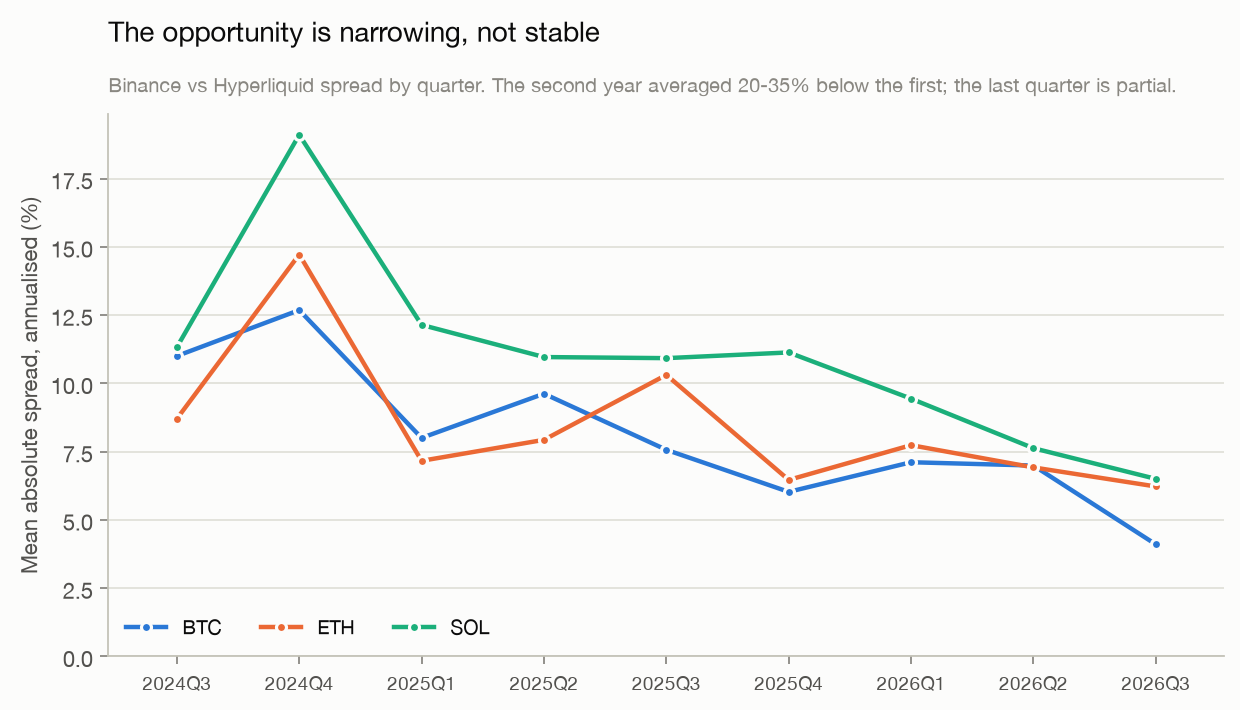

In [18]:
display(Image(filename=f"{FIG}/decay.png"))

The second year of the sample averaged 20–35% below the first, depending on the asset, and the
latest full quarter sits 45–60% below the late-2024 peak. The share of hours clearing a 10%
annualised threshold has fallen with it.

Whether that is competition arriving or simply a quieter market, a backtest run on the full sample
inherits the wider early period and overstates what is available today. This is the most
commercially relevant finding in the notebook and the one an average is most likely to hide.

## 8. One cost that can be measured instead of assumed

Slippage is usually a parameter someone guesses. One component of it need not be: the two legs are
filled on two different order books, and the gap between those books at the moment of execution is
observable from public data.

In [19]:
basis = pipeline.load_basis()
analysis.basis_summary(basis).round(2)

,hours,mean_abs_bps,median_abs_bps,p90_abs_bps,p99_abs_bps,max_abs_bps
BTC,"5,001.00",1.53,1.05,3.41,7.88,14.15
ETH,"5,001.00",1.76,1.22,3.94,8.31,12.05
SOL,"5,001.00",2.02,1.47,4.37,9.89,15.72


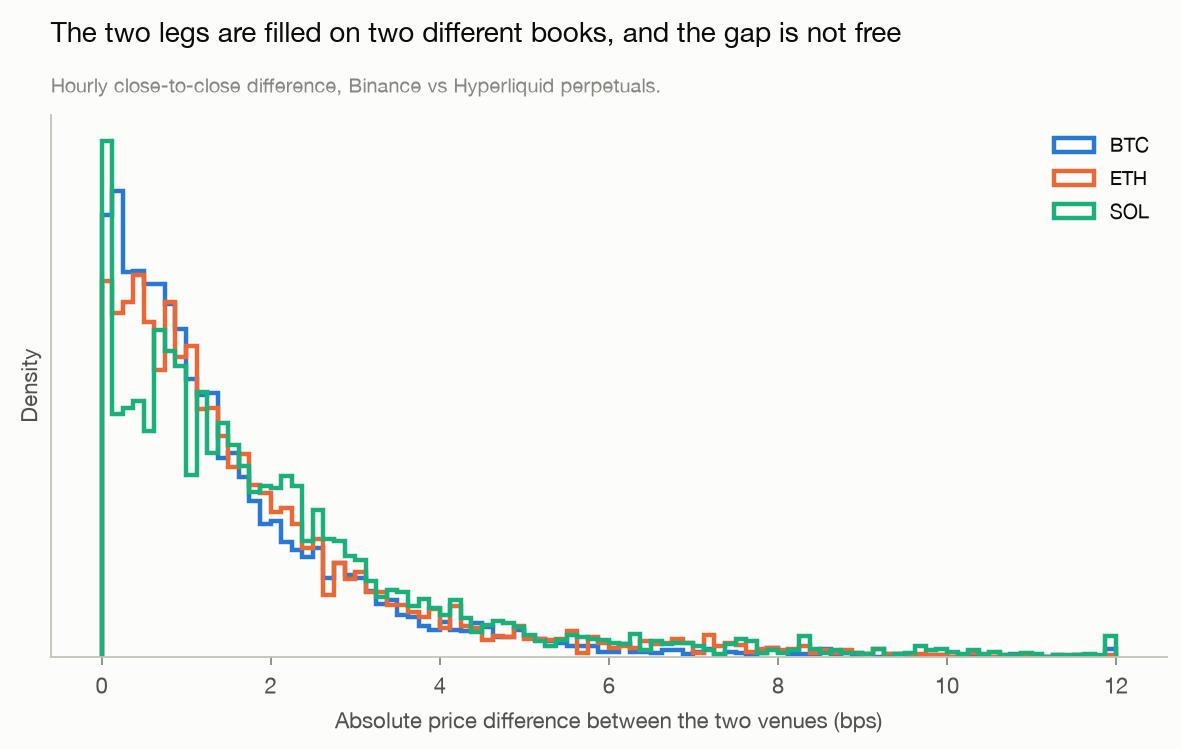

In [20]:
display(Image(filename=f"{FIG}/basis.png"))

A median gap of one to one and a half basis points, with a 99th percentile near ten. Small in
isolation — but the entire fee budget of the cheapest execution profile is four basis points.

At that end of the cost curve, *when* the legs are filled matters as much as *what* the venue
charges. It also caps how far cost optimisation can go: driving fees to zero does not drive the
cost of a two-venue entry to zero.

## 9. Limitations

What this analysis does **not** capture, in rough order of how much it matters:

- **No liquidation modelling.** Both legs post margin independently, and margin is not fungible
  across venues. A sharp move can liquidate the losing leg while the winning one is still open,
  which converts a market-neutral position into a directional one at the worst possible moment.
  This is the dominant tail risk of the strategy and none of it is in these numbers.
- **Returns are quoted on notional, not on capital.** Both legs must be collateralised, so the
  return on deployed capital depends on the margin regime and on leverage — which amplifies the
  liquidation risk above rather than the carry.
- **No counterparty or protocol risk.** Exchange failure and smart-contract failure are real,
  non-diversifiable, and precisely correlated with the moments the strategy is largest.
- **Slippage beyond the measured basis is assumed.** Real fills depend on book depth at the
  instant of execution; only the cross-venue gap was measured here.
- **Funding caps and clamps are ignored.** Venues bound their funding rates, which truncates
  exactly the extreme observations the strategy would most like to capture.
- **Survivorship.** Only currently listed instruments appear in these endpoints, and the three
  assets chosen are the most liquid ones. Smaller assets show wider spreads and thinner books; that
  trade-off is not measured here.
- **OKX publishes only three months of history**, so it constrains any window that includes it and
  is excluded from the two-year comparisons.
- **One historical path.** Two years, three assets, one market regime. Nothing here establishes
  that the relationship holds out of sample.

## 10. Conclusion

**The funding spread between a centralised exchange and an on-chain venue is real and structural.**
It is not an artefact: the same measurement between two centralised exchanges produces a
zero-centred, sign-random control. The DEX pays more roughly two thirds of the time, for an
identifiable reason.

**Almost none of it is tradable in the way the signal invites.** The spread's level mean-reverts
within hours while a round trip costs 13 basis points, so a rule that reacts to the level loses
around 24% a year at retail fees. It earns the most gross income of any rule tested and still
finishes worst.

**What works is the rule that barely trades.** Holding continuously and revisiting only the
direction on a monthly clock returned roughly 4% annualised net on notional, with one to five round
trips over two years, and its ranking is unchanged across every cost profile tested.

**The margin is thinner than it looks and getting thinner.** The spread has halved in two years.
The patient rule survives a round-trip cost above 250 bps; the active one dies above 8. Only the
first of those is a strategy.

The general point is one that transfers well beyond this market: **the edge and the cost of
harvesting it operate on different clocks, and the frequency at which you act — not the quality of
the signal — is what decides whether anything is left.**